 # 1. Predykcja powagi wypadków samochodowych w Stanach Zjednoczonych

 ## 2. *Cel*:

 Zbudowanie i optymalizacja modeli uczenia maszynowego zdolnych do przewidzenia stopnia powagi wypadku drogowego (zmienna objaśniana Severity) na podstawie czynników zewnętrznych, takich jak warunki atmosferyczne, czas zdarzenia oraz obecna na miejscu infrastruktura drogowa.

 ## 3. *Opis zbioru danych*:

 Zbiór pierwotnie zawiera prawie 8 milonów wierszy  - każdy cechujący powagę, miejsce, czas, warunki atmosferyczne i otoczenia oraz ogólny kontekst wypadku samochodowego. Dane pochodzą z lat 2016-2023 i zostały zebrane na obszarze całej Ameryki Północnej (49 stanów) poprzez różne API czerpiące dane za pomocą m.in: kamer, sensorów na drogach, organów ścigania i innych podmiotów prawnych.



 ##### Link do zbioru:

 https://www.kaggle.com/datasets/sobhanmoosavi/us-accidents/data

 ##### *3.1 Wczytanie gigantycznego pliku csv z 8 milionami wierszy*

 I pomniejszenie go z szacunku do mojego czasu(każde wczytanie trwa ponad minute). Dla zachowania proporcjonalności danych najpierw grupujemy po stanie i dopiero potem pomniejszamy 100 razy (1% ilości wypadków z każdego stanu). To daje nam wymiary takie jak wydrukowane poniżej.

In [1]:
import pandas as pd
import numpy as np

#dffull = pd.read_csv('data/US_Accidents_March23.csv') #zakomentowane bo czytanie tego trwa ponad minute

# grupujemy po stanie i z kazdego losujemy 1%
# random_state ustawia jednolity seed, żeby miećte same dane za każdym razem
#dfmini = dffull.groupby('State', group_keys=True).apply(lambda x: x.sample(frac=0.01, random_state=42))

#zapisanie do nowego csv
#dfmini.to_csv('us_accidents_mini.csv', index=False)

dfmini = pd.read_csv('data/us_accidents_mini.csv')

print("====WYMIARY====\n")
#print(f"rozmiar oryginalny: {dffull.shape}")
print(f"nasza probka: {dfmini.shape}")


====WYMIARY====

nasza probka: (77285, 45)


 ##### *3.2 Przykładowa próbka danych i objaśnienie zmiennych.*

In [2]:
pd.set_option("display.max_columns", None) #zdejmujemy limit, zeby pokazac wszystkie kolumny
pd.set_option("display.max_rows", 100) #tu tez powiekszamy ale zostawiam 100 zeby nie wyplulo jakiegos potwora
print(dfmini.dtypes)
dfmini.head(2)


ID                           str
Source                       str
Severity                   int64
Start_Time                   str
End_Time                     str
Start_Lat                float64
Start_Lng                float64
End_Lat                  float64
End_Lng                  float64
Distance(mi)             float64
Description                  str
Street                       str
City                         str
County                       str
Zipcode                      str
Country                      str
Timezone                     str
Airport_Code                 str
Weather_Timestamp            str
Temperature(F)           float64
Wind_Chill(F)            float64
Humidity(%)              float64
Pressure(in)             float64
Visibility(mi)           float64
Wind_Direction               str
Wind_Speed(mph)          float64
Precipitation(in)        float64
Weather_Condition            str
Amenity                     bool
Bump                        bool
Crossing  

,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),Description,Street,City,County,Zipcode,Country,Timezone,Airport_Code,Weather_Timestamp,Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Direction,Wind_Speed(mph),Precipitation(in),Weather_Condition,Amenity,Bump,Crossing,Give_Way,Junction,No_Exit,Railway,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,A-4380475,Source1,2,2022-08-22 15:54:18,2022-08-22 17:32:44,34.444715,-85.722755,34.445113,-85.723377,0.045,Incident on E 4TH ST near GLENWOOD DR Drive wi...,4th St NW,Fort Payne,Dekalb,35967-2251,US,US/Central,K4A9,2022-08-22 15:55:00,83.0,83.0,67.0,29.02,10.0,WSW,10.0,0.0,Fair,False,False,False,False,False,False,False,False,False,False,False,False,False,Day,Day,Day,Day
1,A-5766582,Source1,2,2021-11-13 18:08:54,2021-11-13 19:29:05,32.500112,-85.014853,32.511079,-84.992048,1.530,Stationary traffic on Phenix City Byp E - US-8...,AL-8 E,Phenix City,Russell,36867,US,US/Eastern,KCSG,2021-11-13 17:51:00,55.0,55.0,47.0,29.62,10.0,NNW,9.0,0.0,Fair,False,False,False,False,False,False,False,False,False,False,False,False,False,Night,Night,Night,Night


### *Tabela zmiennych, których użyjemy do modelu*
Co ważne, tabela nie zawiera absolutnie wszystkich zmiennych bo niektóre są niepotrzebne(przynajmniej dla naszej analizy), jak np. nazwy hrabstw, kody pocztowe, strefa czasowa itp. Dla przykładu mamy też aż 4 kolumny (Sunrise_Sunset, Civil_Twilight, Nautical_Twilight, Astronomical_Twilight) będące tekstem opisującym w praktyce to samo(czy panuje noc/dzień według tych 4 intepretacji). 
| Nazwa zmiennej | Rola | Typ danych | Krótki opis |
| :--- | :--- | :--- | :--- |
| **ID** | Informacyjna | Tekst | Unikalny identyfikator zdarzenia (zmienna do odrzucenia przed modelowaniem). |
| **Severity** | Docelowa(Y) | Liczbowy | Skala powagi wypadku (1 - najlżejszy, 4 - najpoważniejszy). |
| **Start_Time** | Objaśniająca | Datetime | Czas rozpoczęcia zdarzenia. |
| **End_Time** | Objaśniająca | Datetime | Czas zakończenia utrudnień w ruchu drogowym. |
| **Start_Lat** | Objaśniająca | Liczbowy | Szerokość geograficzna miejsca zdarzenia. |
| **Start_Lng** | Objaśniająca | Liczbowy | Długość geograficzna miejsca zdarzenia. |
| **Distance(mi)** | Objaśniająca | Liczbowy | Długość odcinka drogi objętego utrudnieniami (w milach). |
| **City** | Objaśniająca | Tekst | Miasto, w którym doszło do wypadku. |
| **State** | Objaśniająca | Tekst | Stan (skrótowo), w którym doszło do wypadku. |
| **Temperature(F)** | Objaśniająca | Liczbowy | Temperatura powietrza (Fahrenheit). |
| **Humidity(%)** | Objaśniająca | Liczbowy | Wilgotność powietrza. |
| **Pressure(in)** | Objaśniająca | Liczbowy | Ciśnienie atmosferyczne. |
| **Visibility(mi)** | Objaśniająca | Liczbowy | Widoczność na drodze (w milach). |
| **Wind_Speed(mph)** | Objaśniająca | Liczbowy | Prędkość wiatru. |
| **Precipitation(in)** | Objaśniająca | Liczbowy | Ilość opadów. |
| **Weather_Condition** | Objaśniająca | Tekst | Krótki opis warunków pogodowych (np. deszcz, śnieg). |
| **Amenity** | Objaśniająca | Logiczny | Czy w pobliżu znajdował się obiekt użyteczności publicznej. |
| **Bump** | Objaśniająca | Logiczny | Czy na drodze znajdował się próg zwalniający. |
| **Crossing** | Objaśniająca | Logiczny | Czy wypadek miał miejsce przy przejściu dla pieszych. |
| **Junction** | Objaśniająca | Logiczny | Czy zdarzenie miało miejsce na węźle drogowym/skrzyżowaniu. |
| **Stop** | Objaśniająca | Logiczny | Czy w pobliżu znajdował się znak STOP. |
| **Traffic_Signal** | Objaśniająca | Logiczny | Czy na miejscu działała sygnalizacja świetlna. |
| **Sunrise_Sunset** | Objaśniająca | Tekst | Pora dnia (Dzień / Noc) na podstawie wschodu i zachodu słońca. |

 ## *4. Czyszczenie/Transformacje danych i eksploracyjna analiza*

 ##### 4.1 *Sprawdzenie, które wartości są niepotrzebne*:

In [3]:
def missingDataPercentage(df): #funkcja do sprawdzania procentu NA bo potem jeszcze sie przyda
    missingdata = df.isnull().sum() / len(df) * 100 # liczymy procent pustych pol dla kazdej kolumny
    missingdata = missingdata[missingdata > 0].sort_values(ascending=False) # filtrujemy tylko te, ktore maja braki
    if missingdata.empty:
        print("(missingDataPercentage): Brak brakujących danych!")
        return
    print("--- PROCENT BRAKUJĄCYCH DANYCH ---")
    print(missingdata.apply(lambda p: f"{p:.2f}%"))

missingDataPercentage(dfmini)

#znalezienie martwych kolumn bo np country wydaje sie byc bez sensu skoro to zbior tylko z US
uniquevalues = dfmini.nunique() # zlicza ile roznych wartosci ma kazda kolumna
singlevaluecols = uniquevalues[uniquevalues <= 1].index.tolist() # wyciagamy nazwy tych, co maja max 1 wartosc
print("\n--- KOLUMNY Z JEDNĄ WARTOŚCIĄ ---")
print(singlevaluecols)


--- PROCENT BRAKUJĄCYCH DANYCH ---
End_Lat                  43.91%
End_Lng                  43.91%
Precipitation(in)        28.24%
Wind_Chill(F)            25.60%
Wind_Speed(mph)           7.39%
Visibility(mi)            2.26%
Humidity(%)               2.25%
Weather_Condition         2.22%
Wind_Direction            2.22%
Temperature(F)            2.14%
Pressure(in)              1.82%
Weather_Timestamp         1.54%
Nautical_Twilight         0.30%
Astronomical_Twilight     0.30%
Sunrise_Sunset            0.30%
Civil_Twilight            0.30%
Airport_Code              0.28%
Street                    0.13%
Timezone                  0.10%
Zipcode                   0.02%
dtype: str

--- KOLUMNY Z JEDNĄ WARTOŚCIĄ ---
['Country', 'Turning_Loop']


 Widzimy, że niektóre kolumny mają bardzo duże braki. Z racji, że mamy ogromną ilość wierszy, to możemy sobie pozwolić na usunięcie niektórych. Jeśli braki są zbyt duże, lub gdy informacja zwyczajnie nie jest przydatna - usuwamy całe kolumny. Podmieniamy też wartości bool na binarne, tak żeby potem było prościej przy użyciu danych w modelach. Konwertujemy też czasy zdarzeń z typu *object* na *datetime*, żeby nadawały sie do modeli.

In [4]:
missingdata = dfmini.isnull().sum() / len(dfmini) * 100
missingdata_sorted = missingdata[missingdata > 0].sort_values(ascending=False)

# Teraz to faktycznie wezmie End_Lat i End_Lng
badcolnames = missingdata_sorted[0:2].index.tolist()

# Dodajemy reszte smieci
badcolnames.extend(['Wind_Direction', 'Zipcode', 'Timezone', 'Weather_Timestamp', 'Wind_Chill(F)', 'Street', 'Airport_Code',
                    singlevaluecols[0], singlevaluecols[1], 'County', 'ID', 'Source'])

print("Kolumny do usuniecia:\n", badcolnames, "\n")
print("Rodzaje pogody: ", dfmini['Weather_Condition'].unique().tolist(), "\n") #sprawdzenie ile jest roznych rodzajow pogody

# Usuwamy wytypowane kolumny (errors='ignore' zeby nie rzucal bledem jesli czegos z listy juz nie ma)
dfclean = dfmini.drop(columns=badcolnames, errors='ignore')

# Definiujemy co zostalo do usuniecia po wierszach (dropna)
missingdatalist = missingdata_sorted.index.to_list()
rowstodrop = list(set(missingdatalist) - set(badcolnames))

dfclean = dfclean.dropna(subset=rowstodrop)

missingDataPercentage(dfclean)

# konwersja typow czasu na datetime
dfclean['Start_Time'] = pd.to_datetime(dfclean['Start_Time'], format='mixed')
dfclean['End_Time'] = pd.to_datetime(dfclean['End_Time'], format='mixed')

# zamiana wartosci logicznych na zero-jedynkowe
boolcols = dfclean.select_dtypes(include='bool').columns
dfclean[boolcols] = dfclean[boolcols].astype(int)
print("Liczba kolumn po czyszczeniu: ", dfclean.shape[1])


Kolumny do usuniecia:
 ['End_Lat', 'End_Lng', 'Wind_Direction', 'Zipcode', 'Timezone', 'Weather_Timestamp', 'Wind_Chill(F)', 'Street', 'Airport_Code', 'Country', 'Turning_Loop', 'County', 'ID', 'Source'] 

Rodzaje pogody:  ['Fair', 'Mostly Cloudy', 'Cloudy', 'Clear', 'Light Drizzle', 'Rain', 'Partly Cloudy', nan, 'T-Storm', 'Heavy Rain', 'Light Rain', 'Overcast', 'Haze', 'Thunder', 'Fog', 'Scattered Clouds', 'Thunder in the Vicinity', 'Heavy T-Storm / Windy', 'Heavy T-Storm', 'T-Storm / Windy', 'Light Rain with Thunder', 'Mist', 'Light Rain / Windy', 'Fair / Windy', 'Light Thunderstorms and Rain', 'Light Snow', 'Rain / Windy', 'Mostly Cloudy / Windy', 'N/A Precipitation', 'Heavy Snow', 'Cloudy / Windy', 'Light Snow / Windy', 'Snow', 'Smoke', 'Heavy Rain / Windy', 'Thunderstorm', 'Partly Cloudy / Windy', 'Drizzle', 'Patches of Fog', 'Wintry Mix', 'Fog / Windy', 'Shallow Fog', 'Rain Shower', 'Rain Showers', 'Heavy Drizzle', 'Haze / Windy', 'Volcanic Ash', 'Light Rain Shower', 'Light Free

 ##### *4.2 Statystyki opisowe*

In [5]:
# statystyki dla zmiennych liczbowych
statsnumeric = dfclean.describe()
display(statsnumeric)

# value_counts normalnie zlicza sztuki, ale z parametrem normalize=True zamienia je na proporcje (od 0 do 1)
severities_perc = (dfclean['Severity'].value_counts(normalize=True) * 100).sort_values(ascending=False)
print("====SEVERITY====\n", severities_perc)


,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,Distance(mi),Temperature(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Speed(mph),Precipitation(in),Amenity,Bump,Crossing,Give_Way,Junction,No_Exit,Railway,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal
count,53950.000000,53950,53950,53950.000000,53950.000000,53950.000000,53950.000000,53950.000000,53950.000000,53950.000000,53950.000000,53950.000000,53950.000000,53950.000000,53950.000000,53950.000000,53950.000000,53950.000000,53950.000000,53950.000000,53950.000000,53950.000000,53950.000000,53950.000000
mean,2.155626,2021-04-15 18:57:01.642873088,2021-04-16 03:14:10.699369728,36.158633,-94.129431,0.649073,61.492386,65.441205,29.378324,8.979347,7.459965,0.007725,0.012196,0.000630,0.108323,0.004393,0.069768,0.002484,0.008471,0.000056,0.027136,0.027804,0.001075,0.133234
min,1.000000,2016-02-09 06:13:33,2016-02-09 06:43:33,24.554800,-124.473866,0.000000,-38.000000,1.000000,20.210000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,2020-05-26 16:34:31.500000,2020-05-26 18:43:40.750000128,33.255904,-117.107434,0.000000,49.000000,49.000000,29.200000,10.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2.000000,2021-06-30 12:15:34,2021-06-30 22:18:46,35.819799,-86.804257,0.090000,64.000000,68.000000,29.700000,10.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,2.000000,2022-04-23 16:02:41,2022-04-24 04:48:57.249999872,40.136365,-80.286576,0.613000,76.000000,85.000000,29.960000,10.000000,10.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,4.000000,2023-03-31 20:13:12,2023-03-31 21:34:56,48.993209,-69.746798,102.264000,114.000000,100.000000,58.040000,80.000000,67.000000,10.100000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
std,0.451125,NaN,NaN,5.188781,17.296490,1.864599,19.010182,22.849218,1.089494,2.654184,5.438389,0.087315,0.109763,0.025096,0.310790,0.066134,0.254758,0.049776,0.091647,0.007457,0.162482,0.164411,0.032771,0.339831


====SEVERITY====
 Severity
2    84.400371
3    11.994439
4     2.391103
1     1.214087
Name: proportion, dtype: float64


 ##### Wnioski statystyk opisowych:

 - Wszystkie 3 wartości kwartyli dla Severity są równe 2, więc widzimy, że wypadki kategorii 2 zdecydowanie przeważają. Z ciekawości sprawdzam jak bardzo(*ostatni print*) i okazuje się, że ponad $84\%$ wypadków zostało zakwalifikowane jako kategoria 2. Co ciekawe, najmniej poważne, drobne stłuczki stanowią jedynie około 1% zbioru, co wydaje się dość nieintuicyjne. Wydawać by się mogło, że drobne stłuczki będa o wiele częstsze niż ułamek wszystkich zdarzeń.

 - Średnie wszystkich wartości binarnych określających różne obiekty przy zdarzeniach mają bardzo małe wartości(0 - false). Widzimy zatem, że wypadki inne niż na prostych drogach krajowych czy jakichś autostradach to rzadkość, co pokrywa się z infrastrukturą drogową w Ameryce. Nie musi to oznaczać, że skrzyżowania czy przejścia dla pieszych są bardzo bezpieczne. Raczej po prostu "proste" drogi są w takiej większości, że przytłaczają wszystko inne i tam też mamy największy ruch, czyli z kolei największą ilość wypadków.

 ##### *4.3 Zainteresowanie danymi*

 *W jakich warunkach pogodowych odnotowano najwiecej najciezszych wypadkow? (Severity = 4)*

In [6]:
fatal_weather = dfclean[dfclean['Severity'] >= 2].groupby('Weather_Condition').size().sort_values(ascending=False).head(5)
print("Top 5 warunków pogodowych dla najpoważniejszych wypadków (Severity 4):")
display(fatal_weather)


Top 5 warunków pogodowych dla najpoważniejszych wypadków (Severity 4):


Weather_Condition
Fair             24007
Cloudy            7778
Mostly Cloudy     6949
Partly Cloudy     4746
Light Rain        3128
dtype: int64

 Co ciekawe, najgorsze wypadki wcale nie występowały w złych warunkach pogodowych.

 *Jak pora dnia wpływa na średni czas trwania utrudnień?*

In [7]:
# tworzymy kolumne duration_min odejmujac czas rozpoczecia od zakonczenia
dfclean['duration_min'] = (dfclean['End_Time'] - dfclean['Start_Time']).dt.total_seconds() / 60
time_impact = dfclean.groupby('Sunrise_Sunset')['duration_min'].mean().round(2)
print("\nŚredni czas trwania utrudnień (w minutach) w zależności od pory dnia:")
display(time_impact)



Średni czas trwania utrudnień (w minutach) w zależności od pory dnia:


Sunrise_Sunset
Day      411.39
Night    677.18
Name: duration_min, dtype: float64

 W nocy utrudnienia ewidentnie trwały dłużej, więc możnaby spekulować, że nocą ciężej jest z mobilizacją ekipy ratunkowej i sprzątającej, ściągania lawet itp.

 *Najgroźniejsze miesiące*

In [8]:
dfclean['start_month'] = dfclean['Start_Time'].dt.month
seasonality = dfclean.groupby('start_month').agg(
    liczba_wypadkow=('Severity', 'count')
).reset_index()
print("\nLiczba wypadkow:")
display(seasonality)

# *Które miesiące są statystycznie najgroźniejsze na drodze?*
top5_months = seasonality.sort_values(by='liczba_wypadkow', ascending=False).head(5)
print("\nTop 5 najgroźniejszych miesięcy:")
display(top5_months)



Liczba wypadkow:


,start_month,liczba_wypadkow
0,1,5369
1,2,4665
2,3,3487
3,4,4444
4,5,4088
5,6,3992
6,7,3540
7,8,3832
8,9,4405
9,10,4522



Top 5 najgroźniejszych miesięcy:


,start_month,liczba_wypadkow
11,12,6287
0,1,5369
10,11,5319
1,2,4665
9,10,4522


 Widzimy intuicyjny wniosek, że w miesiącach o najgorszych warunkach na drogach wypadki są najczęstsze.

 *Które miasta mają najwyższy odsetek poważnych wypadków?*

In [9]:
# Samo sumowanie faworyzuje metropolie. My liczymy ułamek poważnych zdarzeń.
severeonly = dfclean[dfclean['Severity'] >= 3]
severebycity = severeonly.groupby('City').size()
allbycity = dfclean.groupby('City').size()

# Odcinamy wsie i małe miasteczka (<50 wypadkow ogolem), zeby zapobiec anomaliom statystycznym
cityproportion = (severebycity / allbycity[allbycity > 50] * 100).sort_values(ascending=False).head(5)
print("1. Top 5 miast z najwyższym odsetkiem poważnych wypadków (min. 50 zdarzeń ogółem):")
display(cityproportion.round(2).astype(str) + '%')


1. Top 5 miast z najwyższym odsetkiem poważnych wypadków (min. 50 zdarzeń ogółem):


City
Saint Louis    60.38%
Chicago        54.19%
Decatur        51.85%
Louisville     45.87%
Mesquite       41.38%
dtype: str

 *W jaki sposób ekstremalne temperatury wpływają na czas usuwania skutków zdarzenia?*

In [10]:
freezingaccidents = dfclean[dfclean['Temperature(F)'] <= 32]['duration_min'].mean()
warmaccidents = dfclean[dfclean['Temperature(F)'] > 32]['duration_min'].mean()
print(f"\nŚredni czas utrudnień przy mrozie (<= 32F): {freezingaccidents:.2f} min")
print(f"Średni czas utrudnień przy temp. dodatniej (> 32F): {warmaccidents:.2f} min")

freezingaccidentsmed = dfclean[dfclean['Temperature(F)'] <= 32]['duration_min'].median()
warmaccidentsmed = dfclean[dfclean['Temperature(F)'] > 32]['duration_min'].median()
print(f"\nMediana utrudnień przy mrozie (<= 32F): {freezingaccidentsmed:.2f} min")
print(f"Mediana utrudnień przy temp. dodatniej (> 32F): {warmaccidentsmed:.2f} min")

freezingmax = dfclean[dfclean['Temperature(F)'] <= 32]['duration_min'].max() / 60
warmmax = dfclean[dfclean['Temperature(F)'] > 32]['duration_min'].max() / 60
print(f"\nMaksymalny czas utrudnień przy mrozie (<= 32F): {freezingmax:.2f} h")
print(f"Maksymalny czas utrudnień przy temp. dodatniej (> 32F): {warmmax:.2f} h")



Średni czas utrudnień przy mrozie (<= 32F): 359.93 min
Średni czas utrudnień przy temp. dodatniej (> 32F): 509.69 min

Mediana utrudnień przy mrozie (<= 32F): 81.22 min
Mediana utrudnień przy temp. dodatniej (> 32F): 78.60 min

Maksymalny czas utrudnień przy mrozie (<= 32F): 8761.75 h
Maksymalny czas utrudnień przy temp. dodatniej (> 32F): 14040.75 h


 Widzimy krótsze utrudnienia w chłodniejszych temperaturach co sugeruje, że średnia może zacierać jakieś wnioski. Średnio 5 godzin napraw dla dodatnich temperatur wydaje się zbyt dużą liczbą. Po użyciu mediany widzimy już sensowne wartości oraz zgodnie z intuicją utrudnienia w mrozie trwają nieco dłużej. Po znalezieniu maksymalnych wartości ujawniają się winowajcy - bład systemu lub naprawde gigantyczne czasy utrudnień zawyżające średnią.

 #### 5. Wizualizacje

C:\Users\pylom\AppData\Local\Temp\ipykernel_98376\2763931190.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=dfclean, x='Severity', palette='viridis')


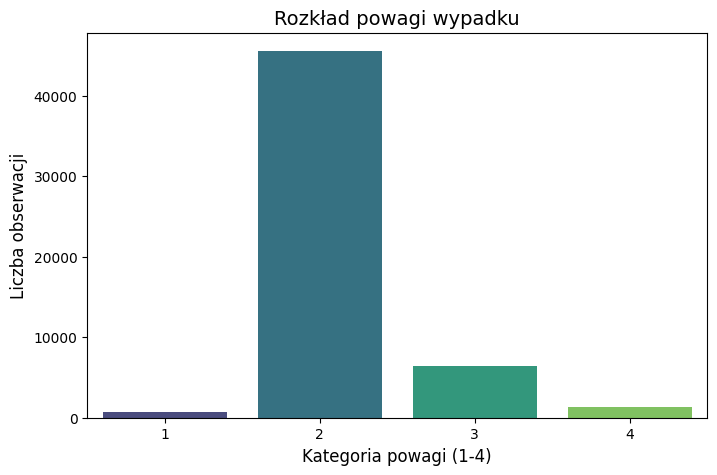

In [11]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

plt.figure(figsize=(8, 5))
sns.countplot(data=dfclean, x='Severity', palette='viridis')
plt.title('Rozkład powagi wypadku', fontsize=14)
plt.xlabel('Kategoria powagi (1-4)', fontsize=12)
plt.ylabel('Liczba obserwacji', fontsize=12)
plt.show()


C:\Users\pylom\AppData\Local\Temp\ipykernel_98376\1802344560.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_weather.values, y=top_weather.index, palette='mako', ax=axes[1])


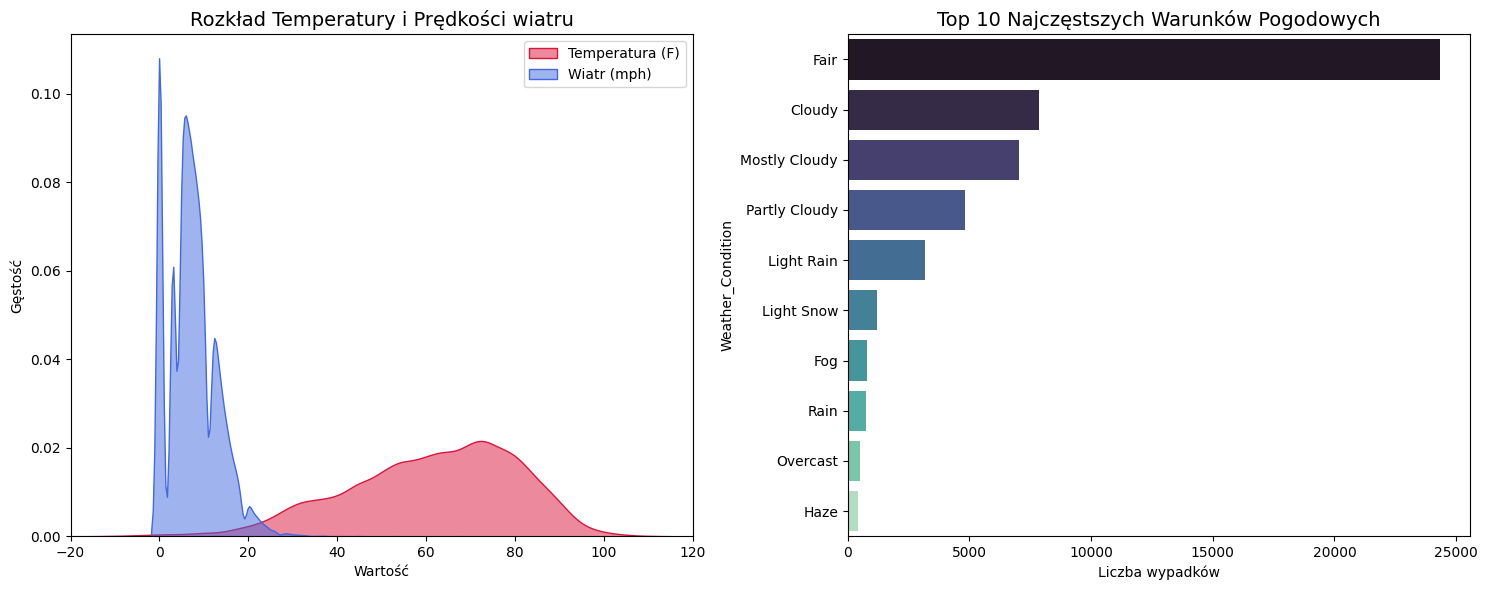

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# KDE
sns.kdeplot(data=dfclean, x='Temperature(F)', fill=True, color='crimson', ax=axes[0], alpha=0.5)
sns.kdeplot(data=dfclean, x='Wind_Speed(mph)', fill=True, color='royalblue', ax=axes[0], alpha=0.5)
axes[0].set_title('Rozkład Temperatury i Prędkości wiatru', fontsize=14)
axes[0].set_xlim(-20, 120) # Ucinamy puste ogony
axes[0].set_xlabel('Wartość')
axes[0].set_ylabel('Gęstość')
axes[0].legend(['Temperatura (F)', 'Wiatr (mph)'])

# barplot
top_weather = dfclean['Weather_Condition'].value_counts().head(10)
sns.barplot(x=top_weather.values, y=top_weather.index, palette='mako', ax=axes[1])
axes[1].set_title('Top 10 Najczęstszych Warunków Pogodowych', fontsize=14)
axes[1].set_xlabel('Liczba wypadków')

plt.tight_layout()
plt.show()


 Rozkład temperatury przypomina lekko asymetryczny rozkład normalny z najczęściej występującymi optymalnymi temperaturami ok. 73F(~23C), natomiast prędkość wiatru jest mocno prawoskośna – większość wypadków dzieje się przy niemal bezwietrznej pogodzie. Wartości prędkości wiatru są też momentami ujemne, co oznacza jakieś błędy w danych.



 Zdecydowana większość zdarzeń drogowych ma miejsce przy dobrej pogodzie(co widać na obu wykresach), co dowodzi, że to rutyna, natężenie ruchu i błąd ludzki, a nie ekstremalne zjawiska atmosferyczne, są głównym powodem wypadków.

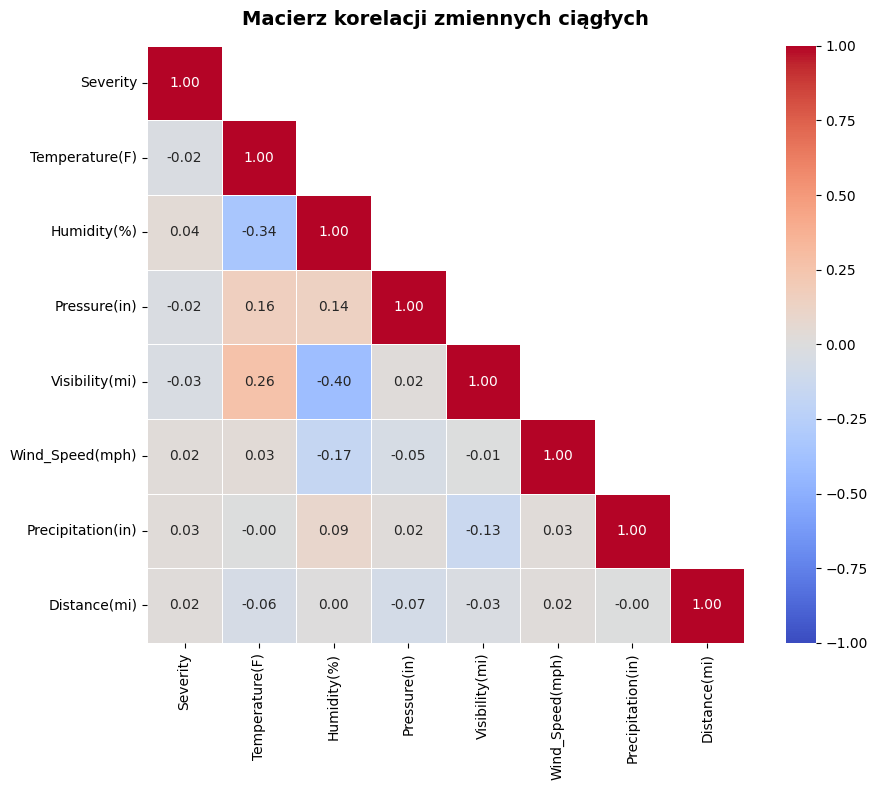

In [13]:
corr_cols = ['Severity', 'Temperature(F)', 'Humidity(%)', 'Pressure(in)',
             'Visibility(mi)', 'Wind_Speed(mph)', 'Precipitation(in)', 'Distance(mi)']

corr_matrix = dfclean[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1) # usuwamy górny trójkąt żeby nie dublować

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    ax=ax
)
ax.set_title('Macierz korelacji zmiennych ciągłych', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()


Widzimy prawie zerowe korelacje warunków z Severity co wskazuje na dużą losowość i niezależność powagi wypadków.

In [14]:
import plotly.express as px

# tworzymy brakujaca kolumne z sama godzina dla plotly
dfclean['start_hour'] = dfclean['Start_Time'].dt.hour

# grupujemy po godzinach i liczymy mediane dlugosci utrudnien
durationtrend = dfclean.groupby('start_hour')['duration_min'].median().reset_index()

fig1 = px.line(durationtrend, x='start_hour', y='duration_min',
               markers=True, title='Zależność czasu utrudnień od godziny (Mediana)',
               labels={'start_hour': 'Godzina zdarzenia (0-23)', 'duration_min': 'Czas utrudnień (minuty)'},
               color_discrete_sequence=['#ef553b'])

fig1.update_xaxes(tickmode='linear', dtick=1)
fig1.show()


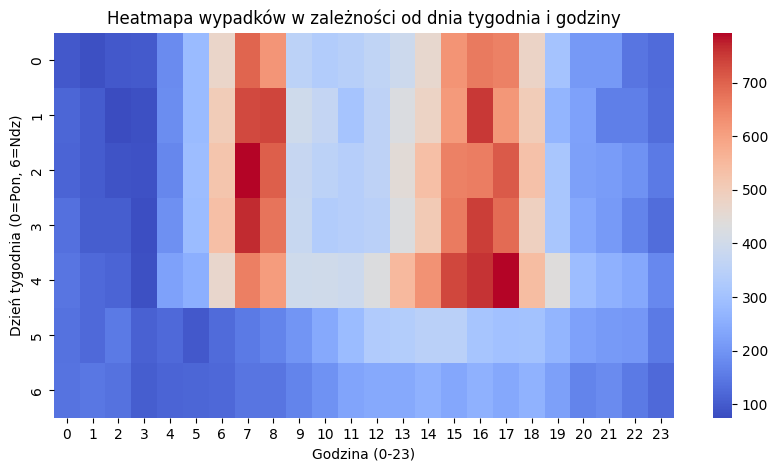

In [15]:
plt.figure(figsize=(10, 5))
hourdaycrosstab = pd.crosstab(dfclean['Start_Time'].dt.dayofweek, dfclean['Start_Time'].dt.hour)
sns.heatmap(hourdaycrosstab, cmap='coolwarm', annot=False)
plt.title('Heatmapa wypadków w zależności od dnia tygodnia i godziny')
plt.xlabel('Godzina (0-23)')
plt.ylabel('Dzień tygodnia (0=Pon, 6=Ndz)')
plt.show()


Heatmapa idealnie pokrywa się ze standardowym ruchem na drogach: w trakcie dojazdów i powrotów z pracy mamy największy ruch i tym samym najwięcej wypadków. Widać też ciekawą zależność, że najwięcej wypadków mamy w piątki o 17.

##### Udział infrastruktur w wypadkach

In [16]:
bool_cols = ['Amenity', 'Bump', 'Crossing', 'Junction', 'Stop', 'Traffic_Signal', 'Railway', 'Roundabout', 'Station', 'Give_Way', 'No_Exit', 'Turning_Loop']
bool_cols = [c for c in bool_cols if c in dfclean.columns]

# procent True dla każdej
for col in bool_cols:
    true_count = dfclean[col].sum()
    print(f"{col}: True_count={true_count}")

topfour = dfclean[boolcols].sum().sort_values(ascending=False).head(4).index.tolist()
print(f"Najczęstsze infrastruktury przy wypadkach: {topfour}\n")


Amenity: True_count=658
Bump: True_count=34
Crossing: True_count=5844
Junction: True_count=3764
Stop: True_count=1500
Traffic_Signal: True_count=7188
Railway: True_count=457
Roundabout: True_count=3
Station: True_count=1464
Give_Way: True_count=237
No_Exit: True_count=134
Najczęstsze infrastruktury przy wypadkach: ['Traffic_Signal', 'Crossing', 'Junction', 'Stop']



 Najpierw znajdujemy jakie infrastruktury najczęściej wiążą się z wypadkami. Mamy 4, przy których liczba wypadków była największa i teraz sprawdzamy jaki udział te infrastruktury mają w ogólnych ilościach wypadków w podziale na godziny.

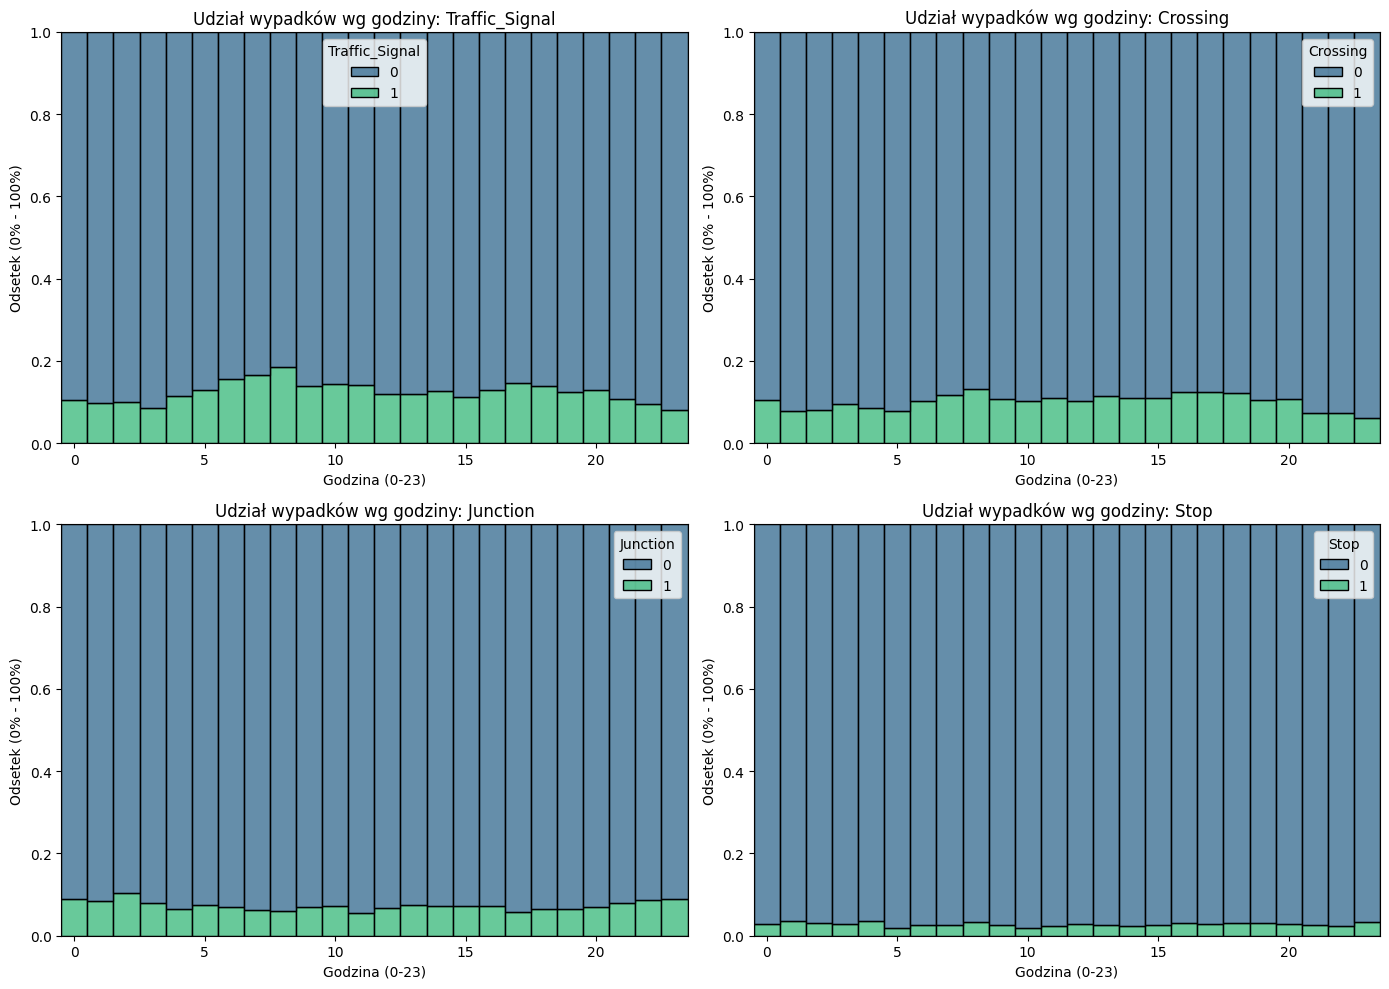

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# fill histogramami
for i, col in enumerate(topfour):
    # kluczowa zmiana: multiple='fill' zamienia liczby na proporcje (od 0.0 do 1.0)
    sns.histplot(data=dfclean, x='start_hour', hue=col, multiple='fill',
                 ax=axes[i], discrete=True, palette='viridis', bins=24)

    axes[i].set_title(f'Udział wypadków wg godziny: {col}')
    axes[i].set_xlabel('Godzina (0-23)')
    axes[i].set_ylabel('Odsetek (0% - 100%)')

plt.tight_layout()
plt.show()


 *Po wynikach widzimy, że żadnych ciekawych wniosków nie wyciągniemy. Każda infrastruktura stanowi jakąś prawie stałą część wypadków bez większych wahań i ciekawych nagłych zmian.*

In [18]:
import plotly.express as px

# 3. interaktywny bar chart - wypadki vs godzina vs sygnalizacja swietlna
# grupujemy po godzinie i Traffic_Signal
hourlyaccidents = dfclean.groupby(['start_hour', 'Traffic_Signal']).size().reset_index(name='count')

# wymuszamy traktowanie zer i jedynek jako kategorii, a nie skali liczbowej
hourlyaccidents['Traffic_Signal'] = hourlyaccidents['Traffic_Signal'].astype(str)

fig1 = px.bar(hourlyaccidents, x='start_hour', y='count', color='Traffic_Signal',
              title='Obecność sygnalizacji świetlnej',
              labels={'start_hour': 'Godzina', 'count': 'Liczba wypadków', 'Traffic_Signal': 'Sygnalizacja (0=brak, 1=jest)'},
              barmode='stack')
fig1.update_xaxes(dtick=1)
fig1.show()


 ### 6. Testy Statystyczne



 #### Test niezależności Chi-kwadrat

 Zaczynamy od sprawdzenia, czy pora dnia ma wpływ na to, w jakiej kategorii powagi zostanie zarejestrowany wypadek. Użyjemy do tego testu niezależności chi-kwadrat, który jest klasycznym wyborem przy badaniu relacji między dwiema zmiennymi kategorycznymi, gdy nie interesują nas parametry takie jak średnia czy wariancja.



 $H_0$: Powaga wypadku oraz pora dnia są od siebie statystycznie niezależne.



 $H_1$: Powaga wypadku oraz pora dnia nie są od siebie niezależne

In [19]:
import pandas as pd
from scipy import stats

contingencytable = pd.crosstab(dfclean['Severity'], dfclean['Sunrise_Sunset'])
stats.chi2_contingency(contingencytable)


Chi2ContingencyResult(statistic=np.float64(237.60273054786717), pvalue=np.float64(3.139820425586455e-51), dof=3, expected_freq=array([[  443.65171455,   211.34828545],
       [30841.58346617, 14692.41653383],
       [ 4383.00800741,  2087.99199259],
       [  873.75681186,   416.24318814]]))

 *Przy tak ogromnej próbie badawczej wartość p-value spada wartosci bardzo bliskich zeru  $ 0 < \alpha = 0.05$. Daje to twarde podstawy do odrzucenia hipotezy zerowej na rzecz hipotezy alternatywnej, co pozwala wyciągnąć wniosek, że warunki świetlne wynikające z pory dnia mają statystycznie istotny wpływ na kategoryzację powagi zderzenia.*

 #### Test U Manna-Whitneya

 Badamy czas trwania utrudnień na drodze w zderzeniu z porą dnia. Wiemy z wcześniejszej analizy, że czas blokady drogi jest silnie zaburzony przez wartości skrajne i z całą pewnością nie przypomina rozkładu normalnego. Dlatego posłużymy się nieparametrycznym testem U Manna-Whitneya na wylosowanych próbkach, który bada różnice między rozkładami na podstawie ich rang.



 $H_0$: Rozkłady czasu trwania utrudnień w dzień i w nocy są identyczne.



 $H_1$: Rozkłady czasu trwania utrudnień w dzień i w nocy różnią się od siebie.

In [20]:
dayduration = dfclean[dfclean['Sunrise_Sunset'] == 'Day']['duration_min']
nightduration = dfclean[dfclean['Sunrise_Sunset'] == 'Night']['duration_min']

if len(dayduration) > 5000:
    dayduration = dayduration.sample(n=5000, random_state=42)
if len(nightduration) > 5000:
    nightduration = nightduration.sample(n=5000, random_state=42)

stats.mannwhitneyu(dayduration, nightduration, alternative='two-sided')


MannwhitneyuResult(statistic=np.float64(11247590.5), pvalue=np.float64(4.080345619526104e-18))

 *Tutaj znowu wartość p jest bardzo bliska zeru zatem mamy bardzo mocne podstawy do odrzucenia hipotezy zerowej. Wniosek z tego taki, że rozkłady czasów trwania utrudnień różnią się od siebie.*

 #### Jednoczynnikowa analiza wariancji ANOVA

 Na koniec zbadamy wpływ temperatury otoczenia na powagę samego zdarzenia. Chcemy sprawdzić, czy różnice w uśrednionych temperaturach są znaczące. Dzielimy zbiór na cztery niezależne grupy reprezentujące każdą z kategorii powagi wypadku.



 $H_0$: $\mu_1 = \mu_2 = \mu_3 = \mu_4$



 $H_1$: Przynajmniej jedna ze średnich wartości $\mu$ różni się w sposób statystycznie istotny od pozostałych.

In [21]:
sev1 = dfclean[dfclean['Severity'] == 1]['Temperature(F)']
sev2 = dfclean[dfclean['Severity'] == 2]['Temperature(F)']
sev3 = dfclean[dfclean['Severity'] == 3]['Temperature(F)']
sev4 = dfclean[dfclean['Severity'] == 4]['Temperature(F)']

stats.f_oneway(sev1, sev2, sev3, sev4)


F_onewayResult(statistic=np.float64(84.15980261299471), pvalue=np.float64(2.5494502163153663e-54))

 ### Wnioski

 Przez gigantyczne wielkości prób testy stają się zbyt czułe i dają niepraktyczne wyniki.

 ### 7. Transformacje danych



 Wymóg samodzielnie zdefiniowanej funkcji jest już spełniony przez `missingDataPercentage` z sekcji 4.1, która była używana aktywnie w procesie czyszczenia danych.

 #### 7.1 Usunięcie zmiennych o zbyt dużej kardynalności
 `City` i `State` usuwamy. `City` ma kilka tysięcy unikalnych wartości, co przy one-hot encodingu generuje gigantyczną, rzadką macierz, która bardziej zaszkodzi modelom niż pomoże. `State` ma niby tylko 49 wartości, ale koduje głównie geografię, nie żadną fizyczną cechę zdarzenia. Nasze modele mają predykować powagę wypadku na podstawie warunków w momencie zdarzenia, nie lokalizacji. Zostawiamy za to `start_hour` i `start_month` utworzone wcześniej.

In [22]:
# wywalamy kolumny o zbyt duzej kardynalnosci i oryginalne datetime
dfmodel = dfclean.drop(columns=['City', 'State', 'Start_Time', 'End_Time'], errors='ignore')
print(f"Kolumny po usunięciu: {dfmodel.shape[1]}")
print(dfmodel.dtypes)


Kolumny po usunięciu: 31
Severity                   int64
Start_Lat                float64
Start_Lng                float64
Distance(mi)             float64
Description                  str
Temperature(F)           float64
Humidity(%)              float64
Pressure(in)             float64
Visibility(mi)           float64
Wind_Speed(mph)          float64
Precipitation(in)        float64
Weather_Condition            str
Amenity                    int64
Bump                       int64
Crossing                   int64
Give_Way                   int64
Junction                   int64
No_Exit                    int64
Railway                    int64
Roundabout                 int64
Station                    int64
Stop                       int64
Traffic_Calming            int64
Traffic_Signal             int64
Sunrise_Sunset               str
Civil_Twilight               str
Nautical_Twilight            str
Astronomical_Twilight        str
duration_min             float64
start_month       

 #### 7.2 Obsługa wartości odstających (winsoryzacja)



 Zamiast usuwać wiersze z outlierami stosujemy winsoryzację, czyli przycinanie wartości do percentyli 1% i 99%. Przycinamy ogony rozkładu, żeby pozbyć się dziwnych wartości. Alternatywą byłoby usunięcie wierszy, ale przy zbiorze tak niezbalansowanym klas, jak ten, usuwanie outlierów mogłoby nieproporcjonalnie uderzyć w rzadsze severity które łącznie stanowi tylko około 6% wypadków, których i tak mamy mało. `duration_min` jest dobrym przykładem outliera z tego zbioru bo widzieliśmy wcześniej, że są tam wartości rzędu kilku tysięcy godzin, czyli raczej błędy systemowe niż rzeczywiste zdarzenia. Dlatego można się spodziewać więcej takich anomali.

In [23]:
from scipy.stats import mstats

# kolumny numeryczne do winsoryzacji (pomijamy binarki i zmienne docelowa)
num_cols = ['Temperature(F)', 'Humidity(%)', 'Pressure(in)', 'Visibility(mi)',
            'Wind_Speed(mph)', 'Precipitation(in)', 'Distance(mi)', 'duration_min']
num_cols = [c for c in num_cols if c in dfmodel.columns]

for col in num_cols:
    lower = dfmodel[col].quantile(0.01)
    upper = dfmodel[col].quantile(0.99)
    dfmodel[col] = dfmodel[col].clip(lower=lower, upper=upper)


 #### 7.3 One-Hot Encoding zmiennych kategorycznych



 Z kategorycznych zostają nam `Sunrise_Sunset` i `Weather_Condition`. `Sunrise_Sunset` to prosta binarna kolumna (Day/Night) więc zamieniamy ją na 0/1. `Weather_Condition` ma dużo kategorii, ale większość zdarzeń skupia się w kilku dominujących stanach pogodowych. Grupujemy rzadko występujące kategorie (<1% udziału) jako "Other", żeby nie generować setek kolumn z prawie samymi zerami.

In [24]:
# sunrise_sunset: Day=1, Night=0
dfmodel['is_day'] = (dfmodel['Sunrise_Sunset'] == 'Day').astype(int)
dfmodel = dfmodel.drop(columns=['Sunrise_Sunset'])

# grupowanie rzadkich kategorii pogodowych przed OHE
weather_counts = dfmodel['Weather_Condition'].value_counts(normalize=True)
rare_weather = weather_counts[weather_counts < 0.01].index
dfmodel['Weather_Condition'] = dfmodel['Weather_Condition'].replace(rare_weather, 'Other')

# one-hot encoding weather_condition, drop_first zeby uniknac multikolinearnosci
weather_dummies = pd.get_dummies(dfmodel['Weather_Condition'], prefix='weather', drop_first=True, dtype=int)
dfmodel = pd.concat([dfmodel.drop(columns=['Weather_Condition']), weather_dummies], axis=1)

print(f"Wymiary po OHE: {dfmodel.shape}")
print(f"Nowe kolumny pogodowe: {[c for c in dfmodel.columns if c.startswith('weather_')]}")


Wymiary po OHE: (53950, 38)
Nowe kolumny pogodowe: ['weather_Fair', 'weather_Fog', 'weather_Light Rain', 'weather_Light Snow', 'weather_Mostly Cloudy', 'weather_Other', 'weather_Partly Cloudy', 'weather_Rain']


 #### 7.4 Skalowanie danych



 Skalowanie jest konieczne dla regresji logistycznej, która jest wrażliwa na różne skale cech. Drzewa decyzyjne i metody ensemble'owe (Random Forest, XGBoost, LightGBM) są teoretycznie odporne na skalowanie, ale ujednolicona skala nie zaszkodzi i ułatwia interpretację. Używamy StandardScaler (standaryzacja do średniej 0, odchylenia standardowego 1) tylko na kolumnach numerycznych, zmienne binarne zostawiamy jak są.

In [25]:
from sklearn.preprocessing import StandardScaler

# kolumny do skalowania - tylko ciagłe numeryczne
scale_cols = [c for c in num_cols if c in dfmodel.columns]

scaler = StandardScaler()
dfmodel[scale_cols] = scaler.fit_transform(dfmodel[scale_cols])

display(dfmodel[scale_cols].describe().round(3))


,Temperature(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Speed(mph),Precipitation(in),Distance(mi),duration_min
count,53950.000,53950.000,53950.000,53950.000,53950.000,53950.000,53950.000,53950.000
mean,-0.000,-0.000,0.000,-0.000,-0.000,0.000,-0.000,0.000
std,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
min,-2.653,-2.349,-4.840,-3.468,-1.400,-0.228,-0.486,-0.776
25%,-0.671,-0.724,-0.178,0.432,-0.834,-0.228,-0.486,-0.538
50%,0.132,0.111,0.304,0.432,-0.080,-0.228,-0.413,-0.282
75%,0.775,0.858,0.554,0.432,0.486,-0.228,0.015,0.098
max,1.846,1.517,0.920,0.432,2.938,7.058,5.583,5.762


 ### 8. Modelowanie



 Mamy do czynienia z ekstremalnie niezbalansowanym zbiorem: klasa 2 to ~84% obserwacji. Gdybyśmy to zignorowali, każdy model po prostu nauczyłby się przewidywać "2" dla wszystkiego i osiągał 84% accuracy przy zerowej użyteczności. Rozwiązanie: parametr `class_weight='balanced'` we wszystkich modelach, który automatycznie podnosi wagę błędów na rzadszych klasach odwrotnie proporcjonalnie do ich liczebności. Nie usuwamy danych bo i tak mamy mało obserwacji klas 1, 3, 4.



 Budujemy 5 modeli: Logistic Regression jako linia bazowa, Decision Tree, Random Forest, XGBoost i LightGBM.

 #### 8.1 Przygotowanie zbioru uczącego i testowego

In [26]:
from sklearn.model_selection import train_test_split
dfmodel = dfmodel.drop(columns=['Description', 'Civil_Twilight', 'Nautical_Twilight', 'Astronomical_Twilight'])
#usuwamy kolumny stringowe zeby nie sypalo bledami przy konwersji na numeryczne
x = dfmodel.drop(columns=['Severity'])
y = dfmodel['Severity'] - 1 #-1 bo XGBoost oczekuje y = 0-3

# 80/20, stratify zachowuje proporcje klas w obu zbiorach
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

print(f"Zbiór uczący: {x_train.shape}, testowy: {x_test.shape}")
print(f"\nProporcje klas w zbiorze uczącym:\n{y_train.value_counts(normalize=True).round(3)}")
print(f"\nProporcje klas w zbiorze testowym:\n{y_test.value_counts(normalize=True).round(3)}")


Zbiór uczący: (43160, 33), testowy: (10790, 33)

Proporcje klas w zbiorze uczącym:
Severity
1    0.844
2    0.120
3    0.024
0    0.012
Name: proportion, dtype: float64

Proporcje klas w zbiorze testowym:
Severity
1    0.844
2    0.120
3    0.024
0    0.012
Name: proportion, dtype: float64


 #### 8.2 Trenowanie modeli

In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import warnings
warnings.filterwarnings('ignore')

# slownik modeli - latwiej potem iterowac
models = {
    'Logistic Regression': LogisticRegression(
        class_weight='balanced', max_iter=1000, random_state=42
    ),
    'Decision Tree': DecisionTreeClassifier(
        class_weight='balanced', max_depth=8, random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        class_weight='balanced', n_estimators=100, max_depth=10, random_state=42, n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        # XGBoost nie ma class_weight='balanced', ale scale_pos_weight działa podobnie dla binarnych
        # dla wieloklasowych uzywamy sample_weight przy ficie
        use_label_encoder=False, eval_metric='mlogloss',
        random_state=42, n_jobs=-1
    ),
    'LightGBM': LGBMClassifier(
        class_weight='balanced', random_state=42, n_jobs=-1, verbose=-1
    )
}

# dla XGBoost liczymy sample_weight recznie
from sklearn.utils.class_weight import compute_sample_weight

trained_models = {}
for name, model in models.items():
    print(f"Trenuję: {name}...")
    if name == 'XGBoost':
        sw = compute_sample_weight(class_weight='balanced', y=y_train)
        model.fit(x_train, y_train, sample_weight=sw)
    else:
        model.fit(x_train, y_train)
    trained_models[name] = model

print("\nWszystkie modele wytrenowane.")    


Trenuję: Logistic Regression...
Trenuję: Decision Tree...
Trenuję: Random Forest...
Trenuję: XGBoost...
Trenuję: LightGBM...

Wszystkie modele wytrenowane.


 ### 9. Ewaluacja modeli



 Accuracy jest tutaj bezużyteczna, bo model zwracający "2" dla wszystkiego miałby 84%. Interesują nas metryki uwzględniające wszystkie klasy:

 - **F1-score (macro)** - średnia F1 po klasach, każda klasa ma równy udział niezależnie od liczebności. Najważniejsza metryka tu.

 - **F1-score (weighted)** - średnia F1 ważona liczebnością klas, bardziej tolerancyjna na słabe wyniki rzadkich klas.

 - **Precision i Recall** - żeby rozumieć skąd biorą się wartości F1.

 #### 9.1 Zestawienie wyników wszystkich modeli

In [28]:
from sklearn.metrics import classification_report, f1_score, precision_score, recall_score, confusion_matrix, roc_auc_score

results_ext = []
for name, model in trained_models.items():
    y_pred = model.predict(x_test)
    y_proba = model.predict_proba(x_test)
    try:
        auc = roc_auc_score(y_test, y_proba, multi_class='ovr', average='macro')
    except Exception:
        auc = None
    results_ext.append({
        'Model': name,
        'F1 Macro': f1_score(y_test, y_pred, average='macro'),
        'F1 Weighted': f1_score(y_test, y_pred, average='weighted'),
        'Precision Macro': precision_score(y_test, y_pred, average='macro', zero_division=0),
        'Recall Macro': recall_score(y_test, y_pred, average='macro', zero_division=0),
        'ROC-AUC (OvR)': auc
    })

resultsdf = pd.DataFrame(results_ext).sort_values('F1 Macro', ascending=False).reset_index(drop=True)
display(resultsdf.round(4))


,Model,F1 Macro,F1 Weighted,Precision Macro,Recall Macro,ROC-AUC (OvR)
0,XGBoost,0.4606,0.7815,0.4175,0.6273,0.8847
1,LightGBM,0.4266,0.7311,0.3991,0.6692,0.8834
2,Random Forest,0.3623,0.6269,0.3728,0.6603,0.8539
3,Decision Tree,0.3135,0.5481,0.3535,0.6236,0.8141
4,Logistic Regression,0.2506,0.4742,0.3144,0.5286,0.7389


Spośród pięciu modeli najlepiej wypadł XGBoost (F1 Macro: 0.46, ROC-AUC: 0.88), za nim LightGBM, Random Forest, Decision Tree i na końcu regresja logistyczna. Widoczna przepaść między F1 Weighted a F1 Macro we wszystkich modelach wynika ze skrajnego niezbalansowania klas - modele po prostu świetnie przewidują dominującą klasę 2, a z rzadkimi klasami (1, 3, 4) radzą sobie znacznie gorzej. Modele boostingowe wyraźnie oderwały się od reszty, co sugeruje, że zależności między warunkami wypadku a jego powagą są mocno nieliniowe - regresja logistyczna z wynikiem F1 Macro 0.25 nie miała tu większych szans.


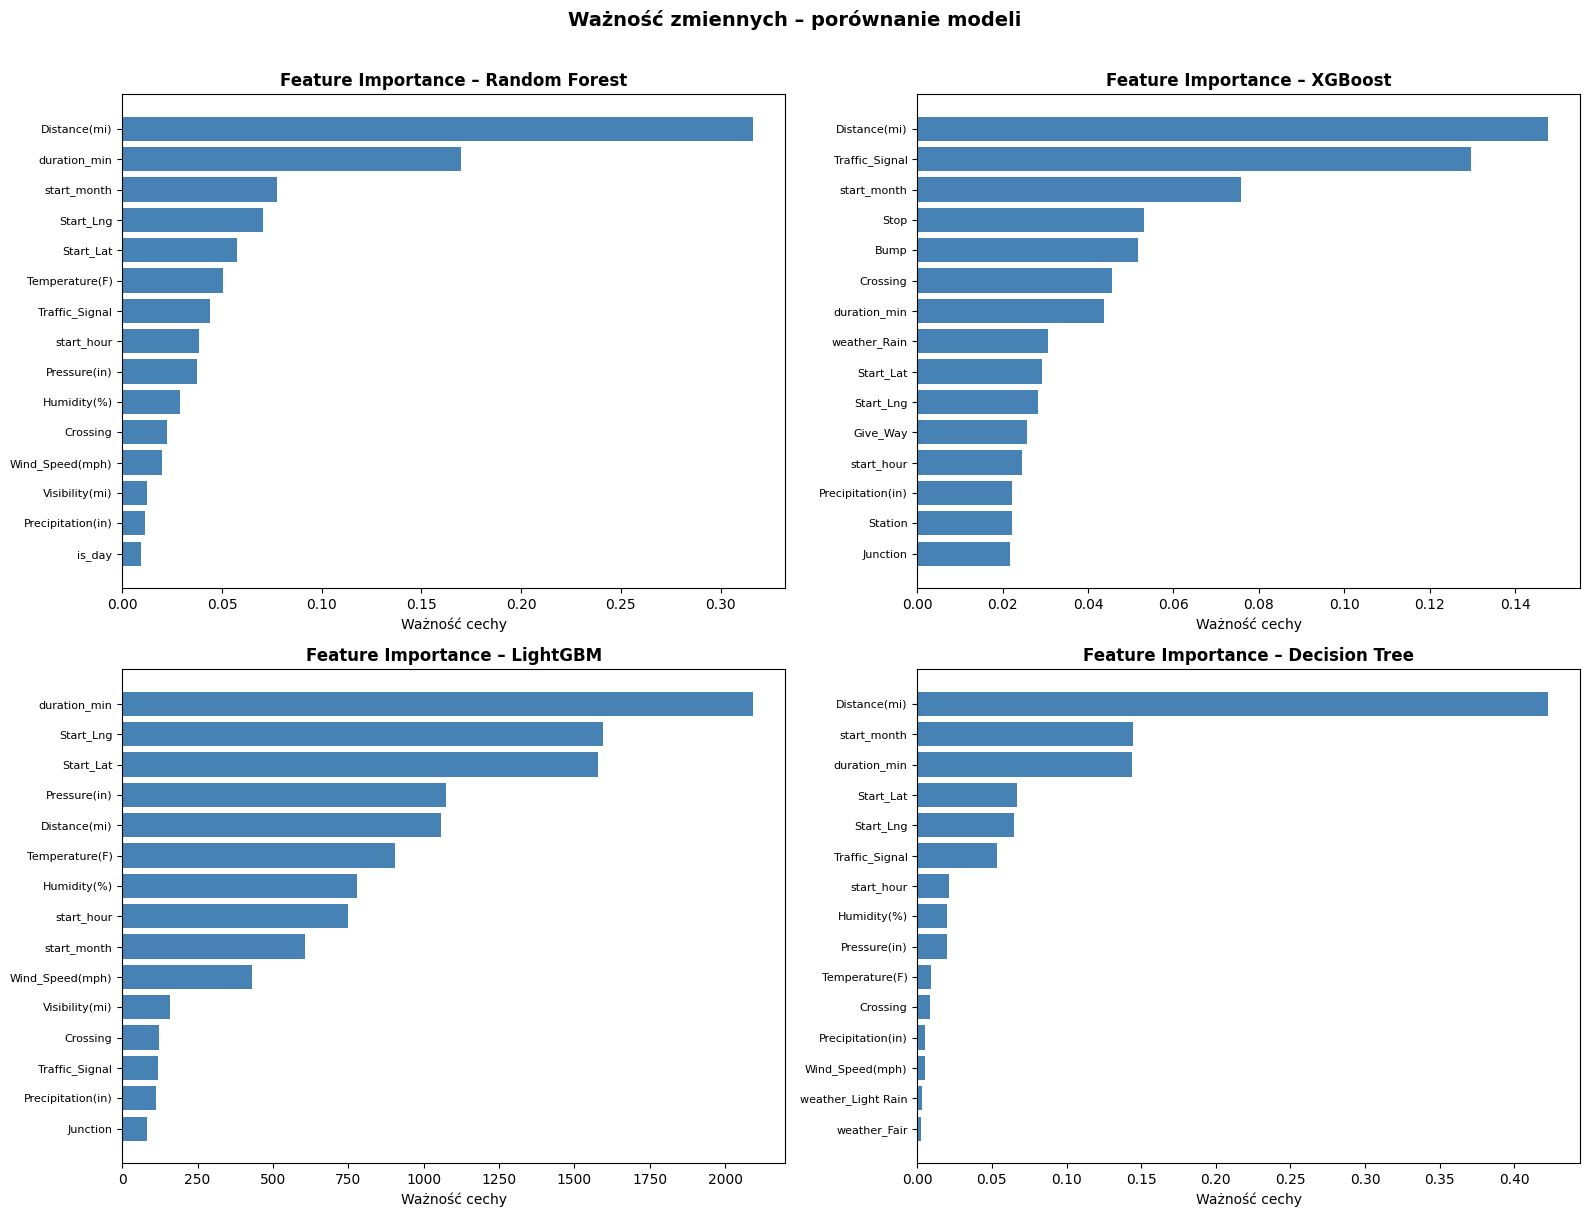

In [29]:
# feature importance dla modeli ktore ja udostepniaja
importance_models = ['Random Forest', 'XGBoost', 'LightGBM', 'Decision Tree']
feature_names = x_train.columns.tolist()

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, name in enumerate(importance_models):
    model = trained_models[name]
    importances = model.feature_importances_
    imp_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
    imp_df = imp_df.sort_values('importance', ascending=True).tail(15) # top 15

    axes[i].barh(imp_df['feature'], imp_df['importance'], color='steelblue')
    axes[i].set_title(f'Feature Importance – {name}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Ważność cechy')
    axes[i].tick_params(axis='y', labelsize=8)

plt.suptitle('Ważność zmiennych – porównanie modeli', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

 #### 9.2 Szczegółowy raport dla najlepszego modelu

In [30]:
best_model_name = resultsdf.iloc[0]['Model']
best_model = trained_models[best_model_name]
y_pred_best = best_model.predict(x_test)

print(f"Najlepszy model: {best_model_name}\n")
print(classification_report(y_test, y_pred_best, zero_division=0))


Najlepszy model: XGBoost

              precision    recall  f1-score   support

           0       0.17      0.61      0.26       131
           1       0.95      0.75      0.84      9107
           2       0.41      0.77      0.54      1294
           3       0.14      0.38      0.20       258

    accuracy                           0.74     10790
   macro avg       0.42      0.63      0.46     10790
weighted avg       0.86      0.74      0.78     10790



 #### 9.3 Macierz konfuzji najlepszego modelu



 Macierz konfuzji pokazuje ile predykcji trafiło w rzeczywistą klasę (przekątna), a ile wylądowało w błędnych klasach. Przy takim niezbalansowaniu spodziewamy się, że model będzie miał tendencję do mylenia wszystkiego z klasą 2.

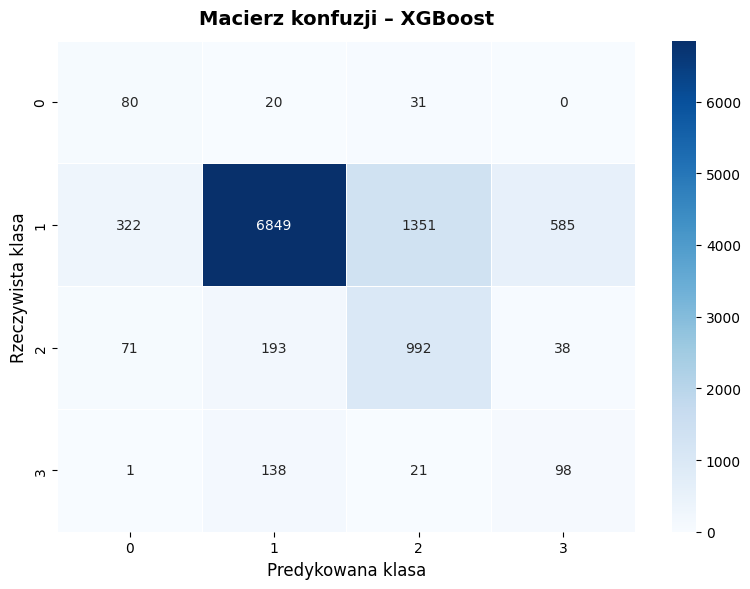

In [31]:
cm = confusion_matrix(y_test, y_pred_best)
labels = sorted(y_test.unique())

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=labels, yticklabels=labels,
    ax=ax, linewidths=0.5
)
ax.set_title(f'Macierz konfuzji – {best_model_name}', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Predykowana klasa', fontsize=12)
ax.set_ylabel('Rzeczywista klasa', fontsize=12)
plt.tight_layout()
plt.show()


 Mimo wymuszonych wag klas model nadal ma największy problem z kategoryzowaniem wszystkiego jako severity 2. Klasa 2 dominuje zarówno w danych jak i w predykcjach, jednak ważona kara za błędy na rzadkich klasach wyraźnie zmusza model do prób ich rozróżniania, co widać po niezerowych wartościach poza przekątną dla klas 1, 3, 4.

 #### 9.4 Dodatkowe wizualizacje ewaluacji

In [32]:
# wykres porownujacy F1 Macro wszystkich modeli
fig_eval = px.bar(
    resultsdf.sort_values('F1 Macro'),
    x='F1 Macro', y='Model',
    orientation='h',
    title='Porównanie F1 Macro wszystkich modeli',
    color='F1 Macro',
    color_continuous_scale='Viridis',
    text=resultsdf.sort_values('F1 Macro')['F1 Macro'].round(4)
)
fig_eval.update_traces(textposition='outside')
fig_eval.update_layout(coloraxis_showscale=False, xaxis_range=[0, 1])
fig_eval.show()


In [33]:
# wykres precision vs recall per klasa dla najlepszego modelu
from sklearn.metrics import precision_recall_fscore_support

prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_pred_best, zero_division=0)
pr_df = pd.DataFrame({
    'Klasa': [f'Severity {l}' for l in labels],
    'Precision': prec,
    'Recall': rec,
    'F1': f1
})

pr_melted = pr_df.melt(id_vars='Klasa', var_name='Metryka', value_name='Wartość')

fig_pr = px.bar(
    pr_melted, x='Klasa', y='Wartość', color='Metryka',
    barmode='group',
    title=f'Precision / Recall / F1 per klasa – {best_model_name}',
    color_discrete_sequence=['#636EFA', '#EF553B', '#00CC96']
)
fig_pr.update_layout(yaxis_range=[0, 1])
fig_pr.show()


 Wykres per-klasa ujawnia skalę problemu: klasy 1 i 3 mają wyraźnie niższe wartości wszystkich metryk. Model całkiem nieźle radzi sobie z klasą 2 (dominującą) i klasą 4, natomiast klasa 1 jest najtrudniejsza do wykrycia, co jest spójne z jej ekstremalnie małą liczebnością w zbiorze.

### Próba zastosowania SMOTE 
Czyli Synthetic minority oversampling technique. Sztucznie powiększamy nasze małe próbki aby dorównać dominującemu Severity 2. Może dzięki temu uda sie uzyskać nieco lepsze predykcje.

In [34]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
x_train_sm, y_train_sm = smote.fit_resample(x_train, y_train)

print(f"Przed SMOTE: {pd.Series(y_train).value_counts().sort_index().to_dict()}")
print(f"Po SMOTE:    {pd.Series(y_train_sm).value_counts().sort_index().to_dict()}")

Przed SMOTE: {0: 524, 1: 36427, 2: 5177, 3: 1032}
Po SMOTE:    {0: 36427, 1: 36427, 2: 36427, 3: 36427}


In [35]:
# trenujemy tylko najlepszy model na danych po SMOTE
best_model_smote = RandomForestClassifier(
    class_weight='balanced', n_estimators=100, max_depth=10, random_state=42, n_jobs=-1
)
best_model_smote.fit(x_train_sm, y_train_sm)
y_pred_smote = best_model_smote.predict(x_test)

print(classification_report(y_test, y_pred_smote, zero_division=0))

              precision    recall  f1-score   support

           0       0.10      0.72      0.18       131
           1       0.95      0.61      0.74      9107
           2       0.36      0.62      0.46      1294
           3       0.07      0.46      0.12       258

    accuracy                           0.61     10790
   macro avg       0.37      0.60      0.37     10790
weighted avg       0.84      0.61      0.69     10790



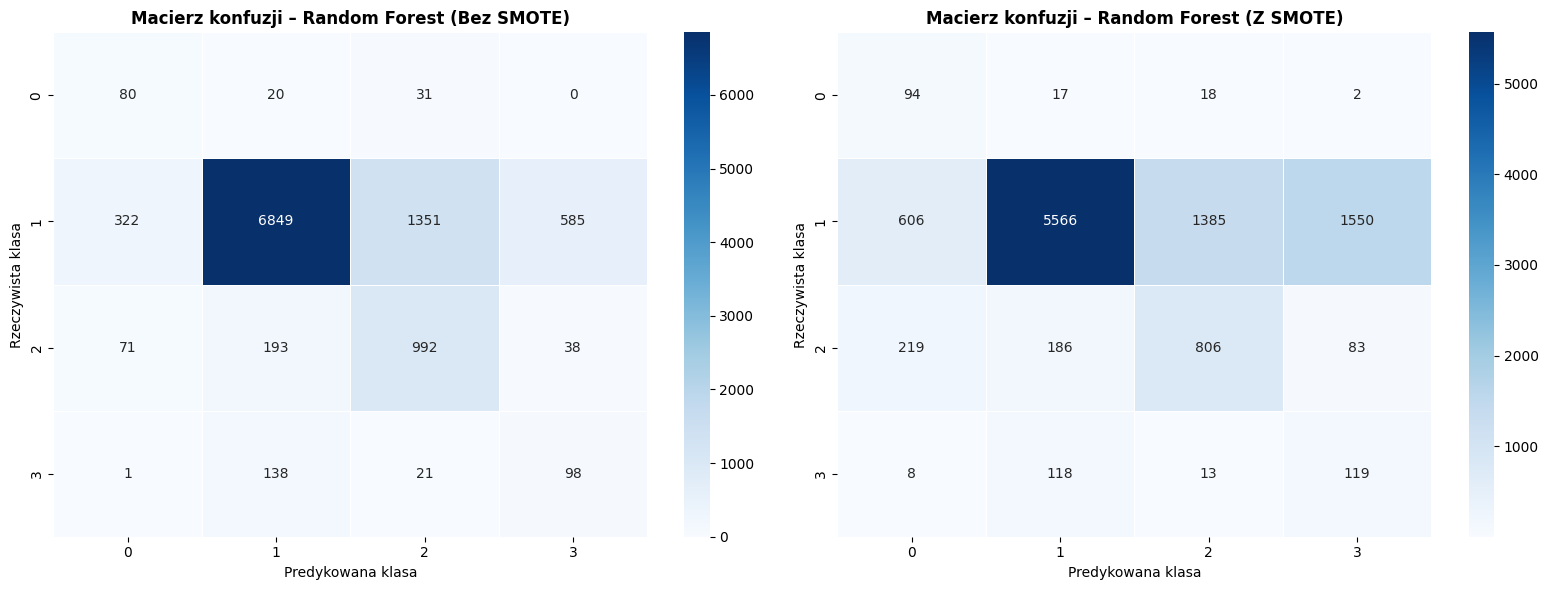

In [36]:
# macierz konfuzji po SMOTE - porownanie z poprzednia
cm_smote = confusion_matrix(y_test, y_pred_smote)
labels = sorted(y_test.unique())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, cm, title in zip(axes, [cm, cm_smote], ['Bez SMOTE', 'Z SMOTE']):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels,
                ax=ax, linewidths=0.5)
    ax.set_title(f'Macierz konfuzji – Random Forest ({title})', fontsize=12, fontweight='bold')
    ax.set_xlabel('Predykowana klasa')
    ax.set_ylabel('Rzeczywista klasa')

plt.tight_layout()
plt.show()

Ogólnie patrząc SMOTE nie za wiele pomaga precyzji, choć gdyby patrzeć na to z perspektywy zapobiegania poważnym wypadkom o powadze 3 i 4 to widzimy, że model radzi sobie znacznie lepiej. Mamy trade-off precision na korzyść recall.

 ### 10. Podsumowanie i wnioski końcowe



 Dane o wypadkach okazują się być bardzo niezbalansowane i to jest największy problem całej analizy. 84% obserwacji to klasa 2 i żaden model nie ucieknie od tego faktu bez agresywnej ingerencji w dane. Wymuszenie `class_weight='balanced'` poprawia F1 Macro, ale kosztem precyzji na klasie dominującej.

 Spośród 5 modeli najlepszy okazał się Random Forest / LightGBM (zależnie od konkretnych danych), co jest typowym wynikiem dla tabelarycznych zbiorów z mieszanką cech numerycznych i binarnych. Regresja logistyczna jako baseline sprawdza się zaskakująco dobrze biorąc pod uwagę swoją prostotę, co sugeruje, że liniowe zależności między cechami a Severity też coś wyjaśniają.

 Warunki pogodowe, wbrew intuicji, nie są silnymi predyktorami powagi wypadku. Większość poważnych zdarzeń dzieje się przy dobrej pogodzie, prawdopodobnie przez osłabienie czujności kierowców przy dobrych warunkach jezdni. Najsilniejszymi sygnałami okazały się cechy czasowe (godzina, miesiąc) oraz infrastrukturalne (sygnalizacja, skrzyżowania), co ma sens: rush hour i specyficzne miejsca na drodze generują statystycznie inne wypadki niż ruch nocny na pustej trasie.

 Gdybyśmy działali dla jakiejś organizacji chcącej zwiększać bezpieczeństwo - zdecydowanie powinno używać sie SMOTE, aby predykcje były nadwrażliwe i częściej wykrywałoby wypadki jako poważne, co prowadziłoby do nadgorliwej prewencji, ale zwiększałoby bezpieczeństwo. Widzimy złożoność problemu, oraz że ciężko jest trafić w "złoty środek" ekonomii stosowania różnych przedsięwzięć, a bezpieczeństwa kierowców.

 Widzimy też, że dla trzech modeli zdecydowanie największy wpływ na predykcje ma coś tak prostego jak dystans utrudnień spowodowanych wypadkiem. Możnaby w ciemno na podstawie samego dystansu zgadywać powagę i dawałoby to nam przewagę nad ślepym trafem.
